<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week2/diabetes_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np;

# 파일 경로 설정
# 이미 전문가에 의해 특징이 추출된 데이터
file_path = '/content/drive/MyDrive/Colab Notebooks/diabetes.csv';

# 데이터 읽기
df = pd.read_csv(file_path);

# 상위 5개 행 확인
# print(df.head());
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 정답(label) 데이터 설정
# Outcome = 당뇨 여부 (0: 정상, 1: 당뇨)
y=df['Outcome'];
y.value_counts();

In [ ]:
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
# 입력 데이터(feature) 생성
# Outcome을 제외한 나머지 변수들을 모델 입력값으로 사용
X=df.drop('Outcome',axis=1)
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
from sklearn.model_selection import train_test_split

# 학습 데이터 / 테스트 데이터 분리
# 25퍼센트를 테스트 케이스로 준다
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [ ]:
X_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
661,1,199,76,43,0,42.9,1.394,22
122,2,107,74,30,100,33.6,0.404,23
113,4,76,62,0,0,34.0,0.391,25
14,5,166,72,19,175,25.8,0.587,51
529,0,111,65,0,0,24.6,0.660,31
...,...,...,...,...,...,...,...,...
366,6,124,72,0,0,27.6,0.368,29
301,2,144,58,33,135,31.6,0.422,25
382,1,109,60,8,182,25.4,0.947,21
140,3,128,78,0,0,21.1,0.268,55


In [ ]:
# Logistic Regression 모델 생성
# 입력 특징을 이용하여 "당뇨일 확률"을 계산하고, 그 확률을 기반으로 0 또는 1로 분류하는 모델
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

# 모델 학습 (훈련 데이터로 패턴 학습)
clf_lr = LogisticRegression(random_state=0) # 머신러닝 모델 빌드
clf_lr.fit(X_train, y_train) # 훈련

pred_lr = clf_lr.predict(X_test) # 예측한 값 입력

# 모델 성능 평가
print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr)) # 전체 예측 중 맞춘 비율
print (confusion_matrix(y_test, pred_lr)) # 실제값 vs 예측값 비교 행렬


--- Logistic Regression Classifier ---
0.796875
[[116  14]
 [ 25  37]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Decision Tree 모델 생성
# 입력 feature 값을 기준으로 데이터를 분할하고
# 가장 잘 클래스가 구분되는 기준을 선택하여 트리 구조로 분류하는 모델
from sklearn.tree import DecisionTreeClassifier

# 모델 학습 (훈련 데이터로 분류 규칙 학습)
clf_dt = DecisionTreeClassifier(random_state=0) # 머신러닝 모델 빌드
clf_dt.fit(X_train, y_train) # 훈련

# 테스트 데이터로 클래스 예측
pred_dt = clf_dt.predict(X_test)

# 모델 성능 평가
print("\n--- Decision Tree Classifier ---")
print(accuracy_score(y_test, pred_dt)) # 전체 예측 중 맞춘 비율
print(confusion_matrix(y_test, pred_dt)) # 실제값 vs 예측값 비교 행렬


--- Decision Tree Classifier ---
0.71875
[[102  28]
 [ 26  36]]


Glucose                     0.317318
DiabetesPedigreeFunction    0.156048
BMI                         0.149355
BloodPressure               0.119571
Age                         0.116088
Pregnancies                 0.065549
SkinThickness               0.041841
Insulin                     0.034229
dtype: float64


<Axes: >

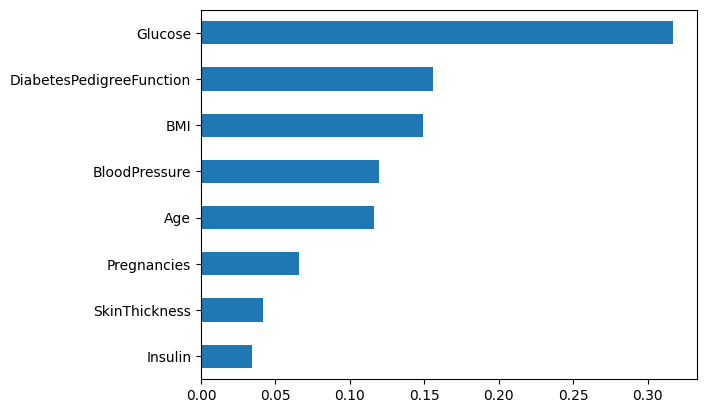

In [ ]:
import pandas as pd

# Decision Tree가 분류에 얼마나 많이 사용했는지를 기준으로 feature 중요도를 시각적으로 확인
feature_importance = pd.Series(clf_dt.feature_importances_, index=X.columns)
feature_importance.sort_values().plot(kind="barh")

In [ ]:
# Random Forest 모델 생성
# 여러 개의 Decision Tree를 학습시킨 뒤, 각 트리의 예측 결과를 종합(투표)하여 분류하는 앙상블 모델
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 (여러 Decision Tree 학습)
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)

# 테스트 데이터 예측
pred_rf = clf_rf.predict(X_test)

# 모델 성능 평가
print("\n--- Random Forest Classifier ---")
print(accuracy_score(y_test, pred_rf))  # 전체 예측 중 맞춘 비율
print(confusion_matrix(y_test, pred_rf))  # 실제값 vs 예측값 비교


--- Random Forest Classifier ---
0.7708333333333334
[[116  14]
 [ 30  32]]
